In [ ]:
import cv2
import torch
import timm
import numpy as np
import matplotlib.pyplot as plt

from PIL import Image
import torchvision.transforms as T
from torchvision import transforms
from sklearn.metrics.pairwise import cosine_similarity
from timm.data import resolve_data_config
from timm.data.transforms_factory import create_transform

from sklearn.decomposition import PCA

In [ ]:
DRAWING_PATH = "examples/drawing.png"
PATTERN_PATH = "examples/pattern.png"

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

SIMILARITY_THRESHOLD = 0.75

MIN_COMPONENT_AREA = 100
MAX_COMPONENT_AREA = 100000

INPUT_SIZE = 518

In [ ]:
def display(images, titles=None, is_binary=False):
    n = len(images)

    width_ratios = [1] + [5] * (n - 1)

    fig = plt.figure(figsize=(5 * n, 5))
    gs = fig.add_gridspec(1, n, width_ratios=width_ratios)

    for i, img in enumerate(images):
        ax = fig.add_subplot(gs[i])
        ax.imshow(img, cmap="gray" if is_binary else None)

        if titles:
            ax.set_title(titles[i], fontsize=20)

        ax.axis("off")

    plt.tight_layout()
    plt.show()

In [ ]:
drawing = cv2.imread(DRAWING_PATH)
pattern = cv2.imread(PATTERN_PATH)

# Verify images loaded correctly
if drawing is None:
    raise ValueError(f"Failed to load drawing image: {DRAWING_PATH}")

if pattern is None:
    raise ValueError(f"Failed to load pattern image: {PATTERN_PATH}")

# Convert BGR -> RGB
drawing_rgb = cv2.cvtColor(drawing, cv2.COLOR_BGR2RGB)
pattern_rgb = cv2.cvtColor(pattern, cv2.COLOR_BGR2RGB)

# Display
display([pattern_rgb, drawing_rgb], titles=["Pattern", "Drawing"])

In [ ]:
class Dinov2Matcher:

  def __init__(self, repo_name="facebookresearch/dinov2", model_name="dinov2_vitb14", smaller_edge_size=448, half_precision=False, device="cuda"):
    self.repo_name = repo_name
    self.model_name = model_name
    self.smaller_edge_size = smaller_edge_size
    self.half_precision = half_precision
    self.device = device

    if self.half_precision:
      self.model = torch.hub.load(repo_or_dir=repo_name, model=model_name).half().to(self.device)
    else:
      self.model = torch.hub.load(repo_or_dir=repo_name, model=model_name).to(self.device)

    self.model.eval()

    self.transform = transforms.Compose([
        transforms.Resize(size=smaller_edge_size, interpolation=transforms.InterpolationMode.BICUBIC, antialias=True),
        transforms.ToTensor(),
        transforms.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)), # imagenet defaults
      ])

  # https://github.com/facebookresearch/dinov2/blob/255861375864acdd830f99fdae3d9db65623dafe/notebooks/features.ipynb
  def prepare_image(self, rgb_image_numpy):
    image = Image.fromarray(rgb_image_numpy)
    image_tensor = self.transform(image)
    resize_scale = image.width / image_tensor.shape[2]

    # Crop image to dimensions that are a multiple of the patch size
    height, width = image_tensor.shape[1:] # C x H x W
    cropped_width, cropped_height = width - width % self.model.patch_size, height - height % self.model.patch_size # crop a bit from right and bottom parts
    image_tensor = image_tensor[:, :cropped_height, :cropped_width]

    grid_size = (cropped_height // self.model.patch_size, cropped_width // self.model.patch_size)
    return image_tensor, grid_size, resize_scale
  
  def prepare_mask(self, mask_image_numpy, grid_size, resize_scale):
    cropped_mask_image_numpy = mask_image_numpy[:int(grid_size[0]*self.model.patch_size*resize_scale), :int(grid_size[1]*self.model.patch_size*resize_scale)]
    image = Image.fromarray(cropped_mask_image_numpy)
    resized_mask = image.resize((grid_size[1], grid_size[0]), resample=Image.Resampling.NEAREST)
    resized_mask = np.asarray(resized_mask).flatten()
    return resized_mask
  
  def extract_features(self, image_tensor):
    with torch.inference_mode():
      if self.half_precision:
        image_batch = image_tensor.unsqueeze(0).half().to(self.device)
      else:
        image_batch = image_tensor.unsqueeze(0).to(self.device)

      tokens = self.model.get_intermediate_layers(image_batch)[0].squeeze()
    return tokens.cpu().numpy()
  
  def idx_to_source_position(self, idx, grid_size, resize_scale):
    row = (idx // grid_size[1])*self.model.patch_size*resize_scale + self.model.patch_size / 2
    col = (idx % grid_size[1])*self.model.patch_size*resize_scale + self.model.patch_size / 2
    return row, col
  
  def get_embedding_visualization(self, tokens, grid_size):
    pca = PCA(n_components=3)
    reduced_tokens = pca.fit_transform(tokens.astype(np.float32))
    reshaped_reduced_tokens = reduced_tokens.reshape((*grid_size, -1))
    normalized_tokens = (reshaped_reduced_tokens-np.min(reshaped_reduced_tokens))/(np.max(reshaped_reduced_tokens)-np.min(reshaped_reduced_tokens))
    return reduced_tokens, normalized_tokens

# Init Dinov2Matcher
dm = Dinov2Matcher(half_precision=False)

image = drawing_rgb

# Extract features
image_tensor, grid_size, resize_scale = dm.prepare_image(image)
features = dm.extract_features(image_tensor)

# Visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10,20))
ax1.imshow(image)
reduced_tokens, vis_image = dm.get_embedding_visualization(features, grid_size)
ax2.imshow(vis_image)
fig.tight_layout()

# More info
print("image.shape:", image.shape)
print("image_tensor.shape:", image_tensor.shape)
print("grid_size:", grid_size)
print("resize_scale:", resize_scale)
print("features.shape:", features.shape)

In [ ]:
from sklearn.cluster import KMeans

km = KMeans(n_clusters=3, random_state=0, n_init=10)
labels = km.fit_predict(reduced_tokens)

# Content cluster = higher mean feature norm
# norms = np.linalg.norm(features, axis=1)
# mean_norm = [norms[labels == k].mean() for k in range(2)]
# content_cluster = int(np.argmax(mean_norm))
# print(f"Content cluster={content_cluster}, mean norms: {mean_norm}")
content_mask_flat = (labels == 2)
content_mask_2d   = content_mask_flat.reshape(grid_size[0], grid_size[1])

In [ ]:
def visualize_mask(drawing_rgb, content_mask_2d, draw_grid, draw_scale, patch_size=14):
    """Show the content mask overlaid on the drawing (Step 2 debug)."""
    gh, gw = draw_grid
    ph = int(gh * patch_size * draw_scale)
    pw = int(gw * patch_size * draw_scale)
    mask_img = (content_mask_2d.astype(np.uint8) * 255)
    mask_big = cv2.resize(mask_img, (pw, ph), interpolation=cv2.INTER_NEAREST)
    h, w = drawing_rgb.shape[:2]
    crop = drawing_rgb[:min(h, ph), :min(w, pw)].copy()
    overlay = crop.copy()
    m = mask_big[:crop.shape[0], :crop.shape[1]] > 0

    ys, xs = np.where(m)

    x_min, x_max = xs.min(), xs.max()
    y_min, y_max = ys.min(), ys.max()

    print("Top-left:    ", (x_min, y_min))
    print("Bottom-right:", (x_max, y_max))
    cropped = drawing_rgb[y_min:y_max+1, x_min:x_max+1]

    overlay[m] = [100, 220, 100]
    blended = cv2.addWeighted(crop, 0.55, overlay, 0.45, 0)

    fig, axes = plt.subplots(1, 3, figsize=(14, 6))
    axes[0].imshow(vis_image); axes[0].set_title("PCA"); axes[0].axis("off")
    axes[1].imshow(blended);     axes[1].set_title("Content mask (green)"); axes[1].axis("off")
    axes[2].imshow(cropped);     axes[2].set_title("Cropped"); axes[2].axis("off")
    plt.tight_layout(); plt.show()

In [ ]:
for k in range(3):
    print(f"Cluster {k}: {(labels == k).sum()} patches")
    content_mask_flat = (labels == k)
    content_mask_2d   = content_mask_flat.reshape(grid_size[0], grid_size[1])
    visualize_mask(drawing_rgb, content_mask_2d, grid_size, resize_scale, dm.model.patch_size)

In [14]:
from PIL import Image
import json
from dino_pattern_detector import DinoPatternDetector, ImageWrapper
from utils import resize_with_scale, turn_to_binary, crop_to_foreground
import torch
import time

detector = DinoPatternDetector(model_name="dinov2_vitb14", device="cuda")

pattern_image = Image.open("examples/pattern.png")
drawing_image = Image.open("examples/drawing.png")
start_time = time.time()
detections, viz = detector.detect(
    pattern_image=pattern_image,
    drawing_image=drawing_image,
    drawing_scales=[1],
    threshold_percentile=99.0,
    nms_iou_threshold=0.05,
    max_detections=30,
    debug=True,
)
end_time = time.time()
print(f"Detection time: {end_time - start_time:.2f} seconds")
viz.save("output.png")

Using device: cuda


Using cache found in /home/vtqn/.cache/torch/hub/facebookresearch_dinov2_main


Saved heatmap to heatmaps/heatmap_drawing_scale_1.00.png
Drawing scale: 1
Drawing grid: 109 x 73
Query grid: 3 x 3
Candidates: [(53, 64, 0.22829972207546234), (15, 36, 0.2204546332359314), (0, 3, 0.21827535331249237), (65, 46, 0.2159607857465744), (52, 44, 0.2150411754846573), (15, 12, 0.21154779195785522), (63, 46, 0.20852746069431305), (52, 42, 0.2084304839372635), (5, 0, 0.20785892009735107), (56, 46, 0.20731045305728912), (29, 22, 0.20710453391075134), (54, 31, 0.20708924531936646), (63, 44, 0.20617757737636566), (48, 42, 0.20456677675247192), (50, 42, 0.2042466402053833), (13, 36, 0.20349577069282532), (54, 17, 0.20317324995994568), (34, 49, 0.20310433208942413), (65, 44, 0.20230741798877716), (39, 51, 0.20132572948932648), (52, 17, 0.20057514309883118), (68, 44, 0.199778750538826), (46, 22, 0.19976778328418732), (63, 21, 0.1992342174053192), (57, 52, 0.1976744383573532), (52, 29, 0.19712823629379272), (34, 47, 0.19609814882278442)]
Detection time: 2.65 seconds


(19, 53)
Resized image size: (19, 53)
(266, 742)
Resized image size: (266, 742)


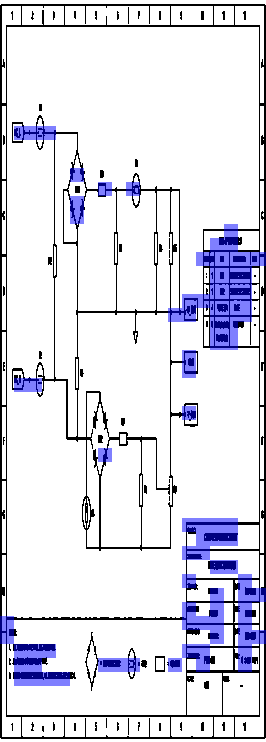

In [ ]:
from PIL import Image
from dino_pattern_detector import ImageWrapper
from utils import turn_to_binary, crop_to_foreground


test_pattern_image = Image.open("examples/drawing.png")
image_wrapper = ImageWrapper(test_pattern_image, patch_size=14, resize_option="resize")
import matplotlib.pyplot as plt
image_list = []
k = 53
for i in [k, k * 14]:
    resized_image = image_wrapper.image.resize((i // 53 * 109, i), Image.Resampling.BICUBIC)
    print(resized_image.size)
    resized_image = turn_to_binary(resized_image)
    resized_image = crop_to_foreground(resized_image)
    image_list.append(resized_image)
    print("Resized image size:", resized_image.size)
    resized_image.save(f"debug/resized_{resized_image.size[0]}x{resized_image.size[1]}.png")

# low-res image (10x10 result)
overlay = image_list[0]

# high-res image (140x140 result)
background = image_list[1]

# Convert to RGBA
overlay = overlay.convert("RGBA")
background = background.convert("RGBA")

# Make white transparent, black -> blue
pixels = overlay.load()
for y in range(overlay.height):
    for x in range(overlay.width):
        r, g, b, a = pixels[x, y]

        # assuming binary image: black foreground, white background
        if r > 128:  # white
            pixels[x, y] = (0, 0, 0, 0)  # fully transparent
        else:        # black
            pixels[x, y] = (0, 0, 255, 128)  # semi-transparent blue

# Scale overlay up to match background size
overlay = overlay.resize(background.size, Image.Resampling.NEAREST)

# Put overlay on top
result = Image.alpha_composite(background, overlay)

result.show()

In [ ]:
# good setting
# detections, vis, debug = detector.detect(
#     pattern_image=pattern,
#     drawing_image=drawing,
#     pattern_scales=[0.75, 0.85, 0.95, 1.0, 1.05, 1.15],
#     threshold_percentile=98.5,
#     nms_iou_threshold=0.05,
#     max_detections=25,
# )

# detections, vis, debug = detector.detect(
#     pattern_image=pattern,
#     drawing_image=drawing,
#     pattern_scales=[0.95],#[0.75, 0.85, 0.95, 1.0, 1.05, 1.15],
#     threshold_percentile=98.5,
#     nms_iou_threshold=0.05,
#     max_detections=25,
# )

# # print(json.dumps(detections, indent=2))
# # print(json.dumps(debug, indent=2))
# vis.save("output.png")